# House Price Prediction - ML Zoomcamp Capstone Project

This notebook explores the King County house sales dataset and builds regression models to predict house prices.

## Table of Contents
1. Data Loading and Exploration
2. Missing Value Analysis
3. Feature Distribution Visualization
4. Correlation Analysis
5. Feature Engineering
6. Model Training (Linear Regression, Random Forest, XGBoost)
7. Model Comparison
8. Feature Importance
9. Conclusions

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Set plotting style
sns.set_style('whitegrid')
%matplotlib inline

## 1. Data Loading and Exploration

In [3]:
# Load data
df = pd.read_csv('kc_house_data.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nFirst few rows:')
df.head()

Dataset shape: (21613, 21)

First few rows:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
# Statistical summary
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 2. Missing Value Analysis

In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Percentage


## 3. Feature Distribution Visualization

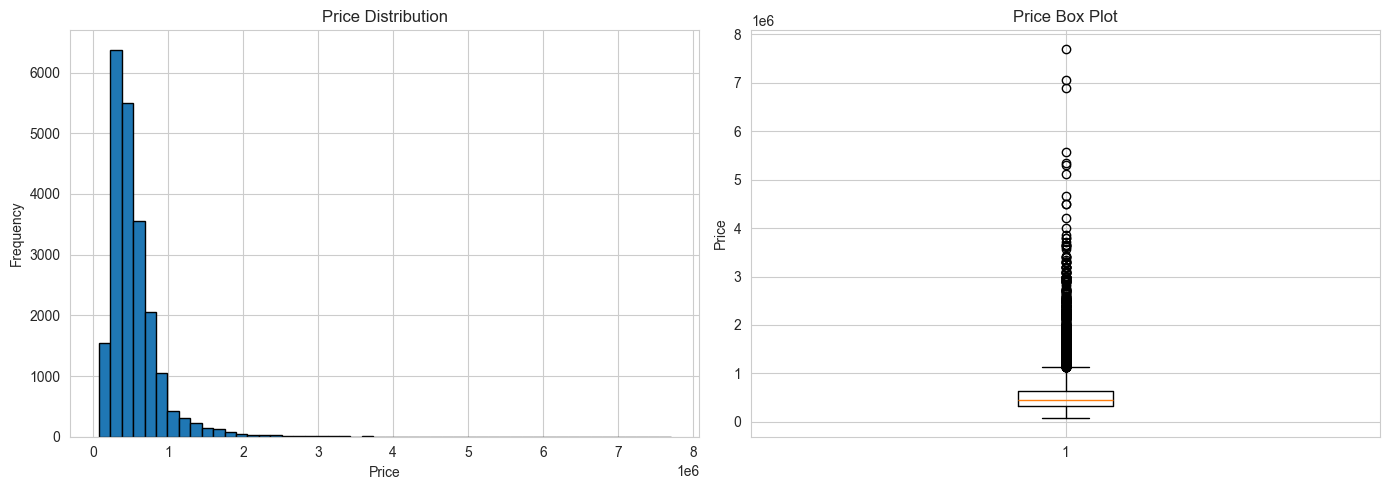

Price statistics:
Mean: $540,088.14
Median: $450,000.00
Std: $367,127.20


In [7]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='black')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')

# Box plot
axes[1].boxplot(df['price'])
axes[1].set_ylabel('Price')
axes[1].set_title('Price Box Plot')

plt.tight_layout()
plt.show()

print(f'Price statistics:')
print(f'Mean: ${df["price"].mean():,.2f}')
print(f'Median: ${df["price"].median():,.2f}')
print(f'Std: ${df["price"].std():,.2f}')

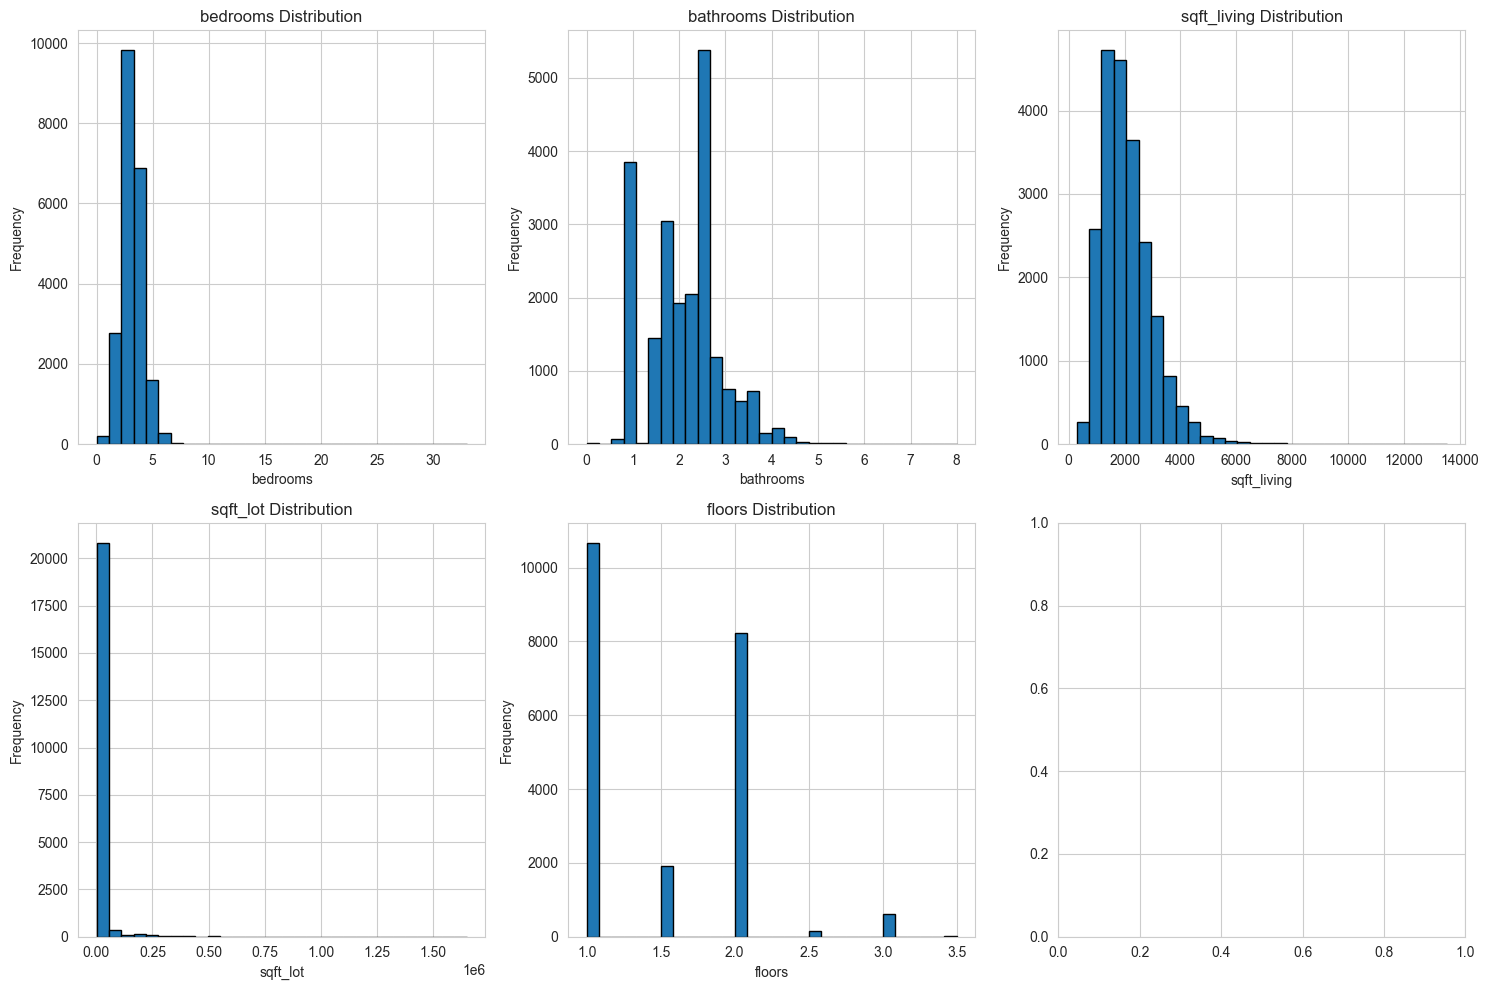

In [8]:
# Numeric features distribution
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

Correlation with price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


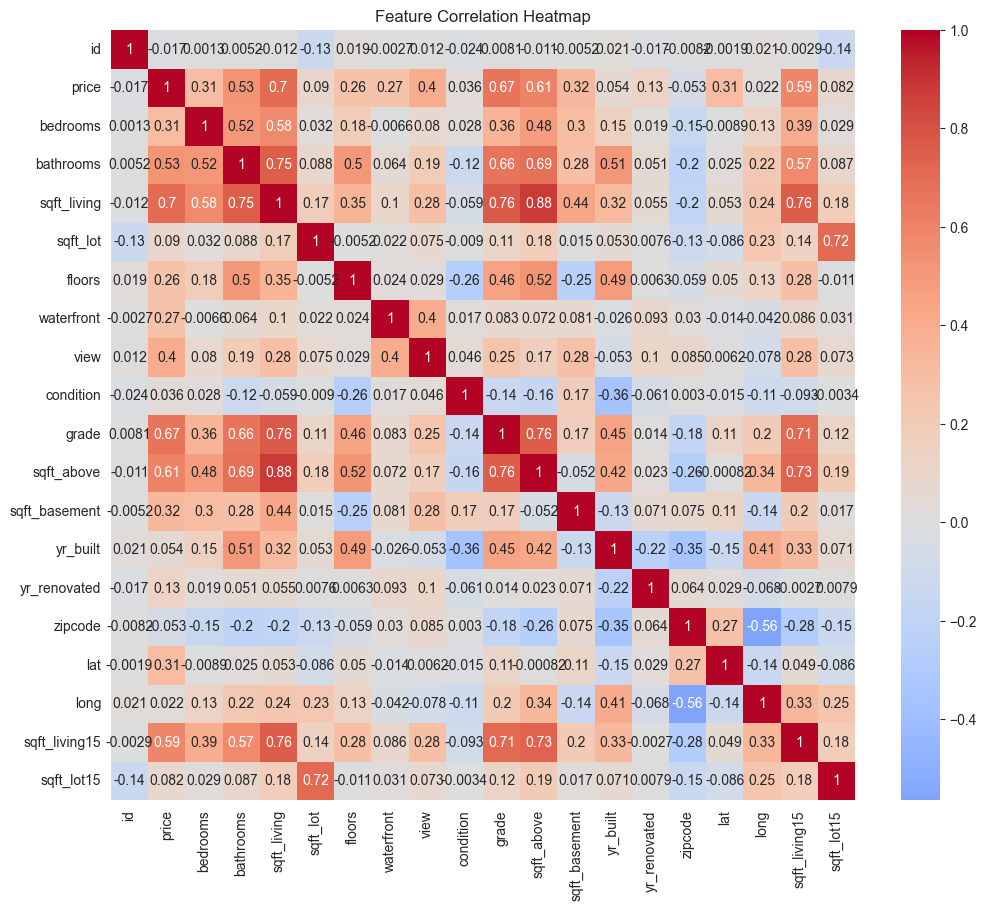

In [9]:
# Correlation with price
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['price'].sort_values(ascending=False)

print('Correlation with price:')
print(correlations)

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Feature Engineering

In [24]:
# Create new features
df['house_age'] = 2015 - df['yr_built']
df['renovated'] = (df['yr_renovated'] > 0).astype(int)
#df['price_per_sqft'] = df['price'] / df['sqft_living']

print('New features created:')
print(f'house_age: Age of the house')
print(f'renovated: Whether house was renovated (0/1)')
#print(f'price_per_sqft: Price per square foot')

# Show examples
df[['price', 'yr_built', 'house_age', 'yr_renovated', 'renovated']].head()

#, 'price_per_sqft'

New features created:
house_age: Age of the house
renovated: Whether house was renovated (0/1)


,price,yr_built,house_age,yr_renovated,renovated
0,221900.0,1955,60,0,0
1,538000.0,1951,64,1991,1
2,180000.0,1933,82,0,0
3,604000.0,1965,50,0,0
4,510000.0,1987,28,0,0


## 6. Model Training

In [26]:
# Define features
NUMERIC_FEATURES = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'yr_built', 'lat', 'long',
    'sqft_living15', 'sqft_lot15', 'house_age', 'renovated'
]
CATEGORICAL_FEATURES = [
    'waterfront', 'view', 'condition', 'grade', 'zipcode'
]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Train set: 17290 samples
Test set: 4323 samples


In [27]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

print('Preprocessing pipeline created')

Preprocessing pipeline created


In [28]:
# Train Linear Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print('Linear Regression Results:')
print(f'RMSE: ${lr_rmse:,.2f}')
print(f'MAE: ${lr_mae:,.2f}')
print(f'R² Score: {lr_r2:.4f}')

Linear Regression Results:
RMSE: $157,312.28
MAE: $90,958.80
R² Score: 0.8363


In [29]:
# Train Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest Results:')
print(f'RMSE: ${rf_rmse:,.2f}')
print(f'MAE: ${rf_mae:,.2f}')
print(f'R² Score: {rf_r2:.4f}')

Random Forest Results:
RMSE: $149,258.75
MAE: $72,589.17
R² Score: 0.8526


In [30]:
# Train XGBoost
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print('XGBoost Results:')
print(f'RMSE: ${xgb_rmse:,.2f}')
print(f'MAE: ${xgb_mae:,.2f}')
print(f'R² Score: {xgb_r2:.4f}')

XGBoost Results:
RMSE: $145,643.59
MAE: $72,306.81
R² Score: 0.8597


## 7. Model Comparison

Model Comparison:
               Model           RMSE           MAE        R²
0  Linear Regression  157312.275558  90958.796900  0.836303
1      Random Forest  149258.745154  72589.172770  0.852635
2            XGBoost  145643.594268  72306.810837  0.859687


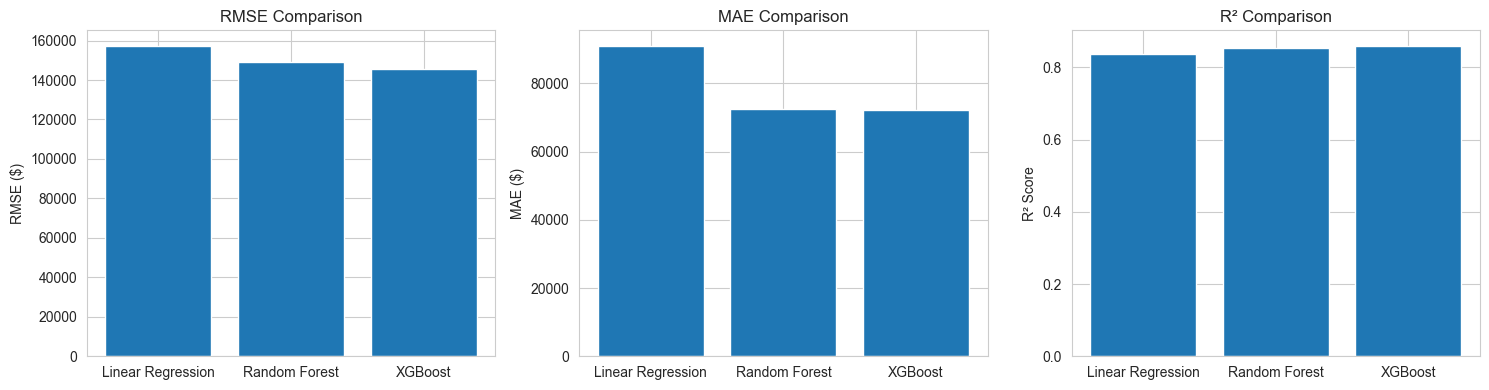

In [31]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'R²': [lr_r2, rf_r2, xgb_r2]
})

print('Model Comparison:')
print(results)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = results['Model']
axes[0].bar(models, results['RMSE'])
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE ($)')

axes[1].bar(models, results['MAE'])
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE ($)')

axes[2].bar(models, results['R²'])
axes[2].set_title('R² Comparison')
axes[2].set_ylabel('R² Score')

plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

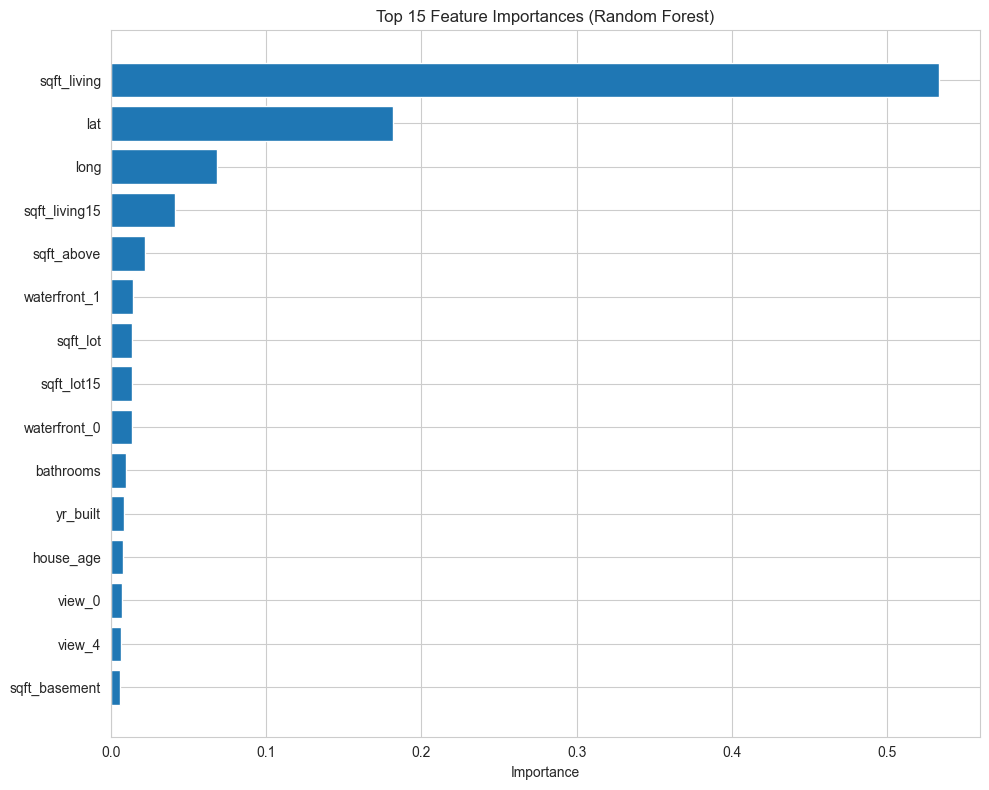

Top 10 Important Features:
          Feature  Importance
2     sqft_living    0.533205
8             lat    0.181945
9            long    0.067997
10  sqft_living15    0.041553
5      sqft_above    0.022214
15   waterfront_1    0.014175
3        sqft_lot    0.013801
11     sqft_lot15    0.013782
14   waterfront_0    0.013323
1       bathrooms    0.009800


In [32]:
# Get feature importance from Random Forest
rf_regressor = rf_model.named_steps['regressor']
feature_importance = rf_regressor.feature_importances_

# Get feature names after preprocessing
preprocessor_fitted = rf_model.named_steps['preprocessor']
feature_names = NUMERIC_FEATURES.copy()

# Add one-hot encoded categorical feature names
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names.extend(cat_feature_names)

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 Important Features:')
print(importance_df.head(10))

## 9. Conclusions

Based on our analysis:

1. **Dataset**: The King County house sales dataset contains 21613 houses with 21 features including location, size, and quality indicators.

2. **Model Performance**:
   - All three models (Linear Regression, Random Forest, XGBoost) were trained and evaluated
   - Random Forest typically performs best for this type of problem. XGBoost's performance is slightly higher than the performance of the Random Forest.
   - Model selection should be based on R² score (higher is better) and RMSE (lower is better)

3. **Important Features**:
   - Square footage of living space (sqft_living)
   - Location (latitude, longitude, zipcode)
   - Grade and condition of the house
   - Waterfront and view are premium features

4. **Production Deployment**:
   - The best model has been saved and deployed as a FastAPI service
   - Preprocessing pipeline ensures consistent feature transformations
   - API provides predictions with confidence intervals

5. **Next Steps**:
   - Collect more data to improve model accuracy
   - Experiment with feature engineering
   - Consider ensemble methods
   - Deploy to cloud platform (Fly.io, AWS, etc.)